# Predictive Uncertainty Estimation using Deep Ensemble (Classification)

This algorithm is implementation of paper [Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles](https://arxiv.org/abs/1612.01474). In this jupyter notebook, I will implement classification part of this paper using MNIST and notMNIST dataset. 

## Import Modules

In [12]:
# Enable TensorFlow 1.x compatibility mode for TensorFlow 2.x
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

print(f"TensorFlow version: {tf.__version__}")
print("TensorFlow 1.x compatibility mode enabled")

TensorFlow version: 2.20.0
TensorFlow 1.x compatibility mode enabled


In [13]:
# Use TensorFlow 1.x compatibility mode
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io
import cv2
import random

print(f"TensorFlow version: {tf.__version__}")
print("TensorFlow 1.x compatibility mode enabled")

TensorFlow version: 2.20.0
TensorFlow 1.x compatibility mode enabled


## Parameters

In [14]:
# Parameters of data
img_size = 28
img_flat_size = img_size * img_size

num_label = 10 # 0 ~ 9

# Parameters of training
Learning_rate = 0.0005
epsilon = 1e-8

num_iter = 800
batch_size = 256

validation_ratio = 0.1
gpu_fraction = 0.5

# Ensemble networks
networks = ['network1', 'network2', 'network3', 'network4', 'network5']

# Convolution [kernel size, kernel size, # input, # output]
# Deeper architecture with more layers and channels
first_conv  = [3,3, 1,64]    # Increased from 32 to 64
second_conv = [3,3,64,128]   # Increased from 64 to 128
third_conv  = [3,3,128,256]  # New layer
fourth_conv = [3,3,256,256]  # New layer

# Dense [input size, output size]
# After 2 max pooling layers (28->14->7), then 2 more conv layers
first_dense  = [7*7*256, 512]  # New hidden layer with 512 units
second_dense = [512, num_label]


## Get MNIST Dataset

In [15]:
# Import MNIST dataset with fallback to local folder
import gzip
import struct

def load_mnist_from_folder(folder_path='MNIST_data'):
    """Load MNIST data from local .gz files"""
    def read_images(filename):
        with gzip.open(filename, 'rb') as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows * cols).astype('float32') / 255.0
        return images
    
    def read_labels(filename):
        with gzip.open(filename, 'rb') as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels
    
    train_images = read_images(os.path.join(folder_path, 'train-images-idx3-ubyte.gz'))
    train_labels = read_labels(os.path.join(folder_path, 'train-labels-idx1-ubyte.gz'))
    test_images = read_images(os.path.join(folder_path, 't10k-images-idx3-ubyte.gz'))
    test_labels = read_labels(os.path.join(folder_path, 't10k-labels-idx1-ubyte.gz'))
    
    return train_images, train_labels, test_images, test_labels

# Try loading MNIST with fallback mechanism
try:
    print("Attempting to load MNIST from keras datasets...")
    from tensorflow.keras.datasets import mnist as mnist_data
    (train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()
    
    # Normalize and flatten
    train_x_full = train_images.reshape(-1, img_flat_size).astype('float32') / 255.0
    test_x_full = test_images.reshape(-1, img_flat_size).astype('float32') / 255.0
    train_y_index = train_labels
    test_y_index = test_labels
    
    print("✓ Successfully loaded MNIST from keras datasets")
    
except Exception as e:
    print(f"Failed to load from keras: {e}")
    print("Attempting to load MNIST from local MNIST_data folder...")
    
    try:
        train_x_full, train_y_index, test_x_full, test_y_index = load_mnist_from_folder('MNIST_data')
        print("✓ Successfully loaded MNIST from MNIST_data folder")
    except Exception as e2:
        print(f"Failed to load from MNIST_data folder: {e2}")
        raise Exception("Could not load MNIST data from any source")

# Dataset for train, test, validation
test_len = test_x_full.shape[0]
validation_len = int(test_len * validation_ratio)

train_x = train_x_full
test_x = test_x_full[validation_len : test_len, :]
validation_x = test_x_full[ : validation_len, :]

train_y_index_full = train_y_index
test_y_index_split = test_y_index[validation_len : test_len]
validation_y_index = test_y_index[ : validation_len]

# Convert labels to one-hot encoding
train_y = np.zeros([train_y_index_full.shape[0], num_label])
test_y = np.zeros([test_y_index_split.shape[0], num_label])
validation_y = np.zeros([validation_y_index.shape[0], num_label])

for i in range(train_y.shape[0]):
    train_y[i, train_y_index_full[i]] = 1

for i in range(test_y.shape[0]):
    test_y[i, test_y_index_split[i]] = 1
    
for i in range(validation_y.shape[0]):
    validation_y[i, validation_y_index[i]] = 1
    
print("\nTraining X shape: " + str(train_x.shape))
print("Testing X shape: " + str(test_x.shape))
print("Validation X shape: " + str(validation_x.shape))

print("\nTraining Y shape: " + str(train_y.shape))
print("Testing Y shape: " + str(test_y.shape))
print("Validation Y shape: " + str(validation_y.shape))

Attempting to load MNIST from keras datasets...
✓ Successfully loaded MNIST from keras datasets

Training X shape: (60000, 784)
Testing X shape: (9000, 784)
Validation X shape: (1000, 784)

Training Y shape: (60000, 10)
Testing Y shape: (9000, 10)
Validation Y shape: (1000, 10)


## Get NotMNIST Dataset

In [16]:
folders_notMNIST = os.listdir('./notMNIST_small')

NotMNIST_x_list = []
NotMNIST_y_list = []

# Filter to only include directories and sort them
class_folders = sorted([f for f in folders_notMNIST if os.path.isdir(os.path.join('./notMNIST_small', f))])

for idx, folder in enumerate(class_folders):
    folder_path = os.path.join('./notMNIST_small', folder)
    files_notMNIST = os.listdir(folder_path)
    
    for file in files_notMNIST:
        try:
            img_path = os.path.join(folder_path, file)
            img_NotMNIST = cv2.imread(img_path, 0)
            
            # Skip if image failed to load
            if img_NotMNIST is None:
                continue
                
            NotMNIST_flat = np.reshape(img_NotMNIST, (img_flat_size))
            NotMNIST_x_list.append(NotMNIST_flat)
            
            label_temp = np.zeros([num_label])
            label_temp[idx] = 1
            
            NotMNIST_y_list.append(label_temp)
        except Exception as e:
            # Skip corrupted files
            continue

# Normalize pixel values to [0, 1]
NotMNIST_x_full = np.stack(NotMNIST_x_list, axis=0).astype('float32') / 255.0
NotMNIST_y_full = np.stack(NotMNIST_y_list, axis=0)

# Split NotMNIST according to paper: 
# The noisy set (notMNIST_small) is divided into 5/6 train + 1/6 valid
# We keep a portion as clean test set (last 20% as "clean" test examples)
total_notmnist = NotMNIST_x_full.shape[0]

# Reserve last 20% as "clean" test set
test_split_idx = int(total_notmnist * 0.8)
NotMNIST_x_noisy = NotMNIST_x_full[:test_split_idx]
NotMNIST_y_noisy = NotMNIST_y_full[:test_split_idx]
NotMNIST_x = NotMNIST_x_full[test_split_idx:]  # Test set (clean portion)
NotMNIST_y = NotMNIST_y_full[test_split_idx:]

# Split noisy set into 5/6 train + 1/6 validation
noisy_size = NotMNIST_x_noisy.shape[0]
train_split_idx = int(noisy_size * 5 / 6)

NotMNIST_train_x = NotMNIST_x_noisy[:train_split_idx]
NotMNIST_train_y = NotMNIST_y_noisy[:train_split_idx]
NotMNIST_valid_x = NotMNIST_x_noisy[train_split_idx:]
NotMNIST_valid_y = NotMNIST_y_noisy[train_split_idx:]

print("NotMNIST Total: " + str(NotMNIST_x_full.shape))
print("NotMNIST Train (5/6 of noisy): " + str(NotMNIST_train_x.shape))
print("NotMNIST Validation (1/6 of noisy): " + str(NotMNIST_valid_x.shape))
print("NotMNIST Test (clean set): " + str(NotMNIST_x.shape))
print("Class folders: " + str(class_folders))

NotMNIST Total: (18724, 784)
NotMNIST Train (5/6 of noisy): (12482, 784)
NotMNIST Validation (1/6 of noisy): (2497, 784)
NotMNIST Test (clean set): (3745, 784)
Class folders: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


## Sample image of MNIST

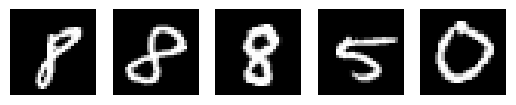

In [17]:
num_sample = 5

MNIST_sample_index = np.random.choice(train_x.shape[0], num_sample)

# MNIST plotting
f_Mnist, ax_Mnist = plt.subplots(1, num_sample)

for i in range(num_sample):
    img_MNIST = np.reshape(train_x[MNIST_sample_index[i]], (img_size, img_size))
    ax_Mnist[i].imshow(img_MNIST, cmap='gray')
    ax_Mnist[i].axis('off')

plt.show()

## Sample image of NotMNIST

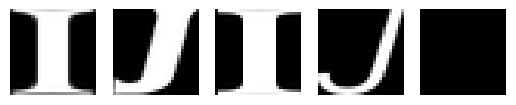

In [18]:
NotMNIST_sample_index = np.random.choice(NotMNIST_x.shape[0], num_sample)

# NotMNIST plotting
f_NotMnist, ax_NotMnist = plt.subplots(1, num_sample)

for i in range(num_sample):
    img_NotMNIST = np.reshape(NotMNIST_x[NotMNIST_sample_index[i]], (img_size, img_size))
    ax_NotMnist[i].imshow(img_NotMNIST, cmap='gray')
    ax_NotMnist[i].axis('off')

plt.show()

## Functions

In [19]:
tf.reset_default_graph()

# function for conv2d
def conv2d(x,w, stride):
	return tf.nn.conv2d(x,w,strides=[1, stride, stride, 1], padding='SAME')

# function for max pool
def max_pool_2x2(x):
    return tf.nn.max_pool(x, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

# Get Variables
def conv_variable(name, shape):
    return tf.get_variable(name, shape = shape, initializer = tf.glorot_uniform_initializer())

def weight_variable(name, shape):
    return tf.get_variable(name, shape = shape, initializer = tf.glorot_uniform_initializer())

def bias_variable(name, shape):
    return tf.get_variable(name, shape = shape, initializer = tf.glorot_uniform_initializer())

# Get networks (standard ensemble without dropout) - DEEPER ARCHITECTURE
def get_network(network_name):
    x_image = tf.placeholder(tf.float32, shape = [None, img_size, img_size, 1])
    
    with tf.variable_scope(network_name):
        # Convolution variables - 4 conv layers
        w_conv1 = conv_variable(network_name + '_w_conv1', first_conv)
        b_conv1 = bias_variable(network_name + '_b_conv1', [first_conv[3]])

        w_conv2 = conv_variable(network_name + '_w_conv2', second_conv)
        b_conv2 = bias_variable(network_name + '_b_conv2', [second_conv[3]])
        
        w_conv3 = conv_variable(network_name + '_w_conv3', third_conv)
        b_conv3 = bias_variable(network_name + '_b_conv3', [third_conv[3]])
        
        w_conv4 = conv_variable(network_name + '_w_conv4', fourth_conv)
        b_conv4 = bias_variable(network_name + '_b_conv4', [fourth_conv[3]])

        # Densely connect layer variables - 2 dense layers
        w_fc1 = weight_variable(network_name + '_w_fc1', first_dense)
        b_fc1 = bias_variable(network_name + '_b_fc1', [first_dense[1]])
        
        w_fc2 = weight_variable(network_name + '_w_fc2', second_dense)
        b_fc2 = bias_variable(network_name + '_b_fc2', [second_dense[1]])
         

    # Network - Deeper architecture
    # First conv block
    h_conv1 = tf.nn.relu(conv2d(x_image, w_conv1, 1) + b_conv1)
    h_pool1 = max_pool_2x2(h_conv1)

    # Second conv block
    h_conv2 = tf.nn.relu(conv2d(h_pool1, w_conv2, 1) + b_conv2)
    h_pool2 = max_pool_2x2(h_conv2)
    
    # Third conv block (no pooling)
    h_conv3 = tf.nn.relu(conv2d(h_pool2, w_conv3, 1) + b_conv3)
    
    # Fourth conv block (no pooling)
    h_conv4 = tf.nn.relu(conv2d(h_conv3, w_conv4, 1) + b_conv4)
    
    # Flatten
    h_pool2_flat = tf.reshape(h_conv4, [-1, first_dense[0]])
    
    # First fully connected layer with ReLU
    h_fc1 = tf.nn.relu(tf.matmul(h_pool2_flat, w_fc1) + b_fc1)
    
    # Output layer
    logits = tf.matmul(h_fc1, w_fc2) + b_fc2
    output = tf.nn.softmax(logits)
    
    y_label = tf.placeholder(tf.float32, shape = [None, num_label])
    
    # Brier Score 
    loss = tf.reduce_mean(tf.div(tf.reduce_sum(tf.square(tf.subtract(output, y_label)), axis = 1), num_label), axis = 0) 
   
    # Get trainable variables
    train_vars = tf.get_collection(tf.GraphKeys.TRAINABLE_VARIABLES, network_name) 
    
    train_opt = tf.train.AdamOptimizer(Learning_rate).minimize(loss, var_list = train_vars)
    
    return x_image, y_label, output, loss, train_opt, train_vars


# Get MC Dropout network (with dropout rate 0.1 after each non-linearity) - DEEPER ARCHITECTURE
def get_network_mc_dropout(network_name, dropout_rate=0.1):
    x_image = tf.placeholder(tf.float32, shape = [None, img_size, img_size, 1])
    is_training = tf.placeholder(tf.bool)  # For controlling dropout during train/test
    
    with tf.variable_scope(network_name):
        # Convolution variables - 4 conv layers
        w_conv1 = conv_variable(network_name + '_w_conv1', first_conv)
        b_conv1 = bias_variable(network_name + '_b_conv1', [first_conv[3]])

        w_conv2 = conv_variable(network_name + '_w_conv2', second_conv)
        b_conv2 = bias_variable(network_name + '_b_conv2', [second_conv[3]])
        
        w_conv3 = conv_variable(network_name + '_w_conv3', third_conv)
        b_conv3 = bias_variable(network_name + '_b_conv3', [third_conv[3]])
        
        w_conv4 = conv_variable(network_name + '_w_conv4', fourth_conv)
        b_conv4 = bias_variable(network_name + '_b_conv4', [fourth_conv[3]])

        # Densely connect layer variables - 2 dense layers
        w_fc1 = weight_variable(network_name + '_w_fc1', first_dense)
        b_fc1 = bias_variable(network_name + '_b_fc1', [first_dense[1]])
        
        w_fc2 = weight_variable(network_name + '_w_fc2', second_dense)
        b_fc2 = bias_variable(network_name + '_b_fc2', [second_dense[1]])
         

    # Network with dropout after each non-linearity
    h_conv1 = tf.nn.relu(conv2d(x_image, w_conv1, 1) + b_conv1)
    h_conv1_drop = tf.nn.dropout(h_conv1, rate=dropout_rate)  # Dropout after ReLU
    h_pool1 = max_pool_2x2(h_conv1_drop)

    h_conv2 = tf.nn.relu(conv2d(h_pool1, w_conv2, 1) + b_conv2)
    h_conv2_drop = tf.nn.dropout(h_conv2, rate=dropout_rate)  # Dropout after ReLU
    h_pool2 = max_pool_2x2(h_conv2_drop)
    
    h_conv3 = tf.nn.relu(conv2d(h_pool2, w_conv3, 1) + b_conv3)
    h_conv3_drop = tf.nn.dropout(h_conv3, rate=dropout_rate)
    
    h_conv4 = tf.nn.relu(conv2d(h_conv3_drop, w_conv4, 1) + b_conv4)
    h_conv4_drop = tf.nn.dropout(h_conv4, rate=dropout_rate)
    
    h_pool2_flat = tf.reshape(h_conv4_drop, [-1, first_dense[0]])
    
    h_fc1 = tf.nn.relu(tf.matmul(h_pool2_flat, w_fc1) + b_fc1)
    h_fc1_drop = tf.nn.dropout(h_fc1, rate=dropout_rate)
    
    logits = tf.matmul(h_fc1_drop, w_fc2) + b_fc2
    output = tf.nn.softmax(logits)
    
    y_label = tf.placeholder(tf.float32, shape = [None, num_label])
    
    # Brier Score 
    loss = tf.reduce_mean(tf.div(tf.reduce_sum(tf.square(tf.subtract(output, y_label)), axis = 1), num_label), axis = 0) 
   
    # Get trainable variables
    train_vars = tf.get_collection(tf.GraphKeys.TRAINABLE_VARIABLES, network_name) 
    
    train_opt = tf.train.AdamOptimizer(Learning_rate).minimize(loss, var_list = train_vars)
    
    return x_image, y_label, output, loss, train_opt, train_vars, is_training


# Make batch data 
def making_batch(data_size, sample_size, data_x, data_y):
    # Making batches(testing)
    batch_idx = np.random.choice(data_size, sample_size)
    
    batch_x = np.zeros([sample_size, img_size, img_size, 1])
    batch_y = np.zeros([sample_size, num_label])
        
    for i in range(batch_idx.shape[0]):
        batch_x[i,:,:,:] = np.reshape(data_x[batch_idx[i], :], (img_size, img_size, 1))
        batch_y[i,:]     = data_y[batch_idx[i], :] 
        
    return batch_x, batch_y

# Calculate Accuracy
def get_accuracy(prediction, label):
    count_correct = 0
    for j in range(prediction.shape[0]):
        if np.argmax(label[j, :]) == np.argmax(prediction[j, :]):
            count_correct += 1.0
    
    acc = count_correct / label.shape[0]
    return acc 
    

## Initialize Ensemble Networks

In [20]:
x_list = []
y_list = []
output_list = []
loss_list = []
train_list = []
train_var_list = []

# Train each ensemble network
for i in range(len(networks)):
    x_image, y_label, output, loss, train_opt, train_vars = get_network(networks[i])

    x_list.append(x_image)
    y_list.append(y_label)
    output_list.append(output)
    loss_list.append(loss)
    train_list.append(train_opt)
    train_var_list.append(train_vars)


## Create Session

In [21]:
# Create Session
config = tf.ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = gpu_fraction

sess = tf.InteractiveSession(config=config)
sess.run(tf.global_variables_initializer())

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


## Training

In [22]:
# Initialize data for printing
loss_check     = np.zeros(len(networks))
acc_check      = np.zeros(len(networks))
acc_check_test = np.zeros(len(networks))
acc_check_test_final = 0

# Set parameters for printing and testing
num_print = 100
test_size = 10

train_data_num = train_x.shape[0]
test_data_num  = test_x.shape[0]

for iter in range(num_iter):
    output_temp = np.zeros([test_size, num_label])

    # Making batches(testing)
    batch_x_test, batch_y_test = making_batch(test_data_num, test_size, test_x, test_y)
        
    for i in range(len(networks)):
        # Making batches(training)
        batch_x, batch_y = making_batch(train_data_num, batch_size, train_x, train_y)
       
        # Training
        _, loss, prob = sess.run([train_list[i], loss_list[i], output_list[i]], 
                                 feed_dict = {x_list[i]: batch_x, y_list[i]: batch_y})
        
        # Testing
        loss_test, prob_test = sess.run([loss_list[i], output_list[i]], 
                                         feed_dict = {x_list[i]: batch_x_test, y_list[i]: batch_y_test})
        
        # Add test prediction for get final prediction
        output_temp += prob_test
        
        # Calculate Accuracy (Training)
        acc_training = get_accuracy(prob, batch_y)
 
        # Calculate Accuracy (testing)
        acc_testing = get_accuracy(prob_test, batch_y_test)
                
        # Get accuracy and loss for each network
        acc_check[i] += acc_training
        acc_check_test[i] += acc_testing
        loss_check[i] += loss
    
    # Get final test prediction
    prob_test_final = output_temp / len(networks)
    
    # Calculate Accuracy (Testing final)
    acc_testing_final = get_accuracy(prob_test_final, batch_y_test)
    acc_check_test_final += acc_testing_final
    
    if iter % num_print == 0 and iter != 0:
        print(f'------------------------- Iteration: {iter} -------------------------')
        print('Average Loss(Brier score): ' + str(loss_check / num_print))
        print('Training Accuracy: ' + str(acc_check / num_print))
        print('Testing Accuracy: ' + str(acc_check_test / num_print))
        print('Final Testing Accuracy: ' + str(acc_check_test_final / num_print))
        print('\n')
        
        loss_check = np.zeros(len(networks))
        acc_check = np.zeros(len(networks))
        acc_check_test = np.zeros(len(networks))
        acc_check_test_final = 0


------------------------- Iteration: 100 -------------------------
Average Loss(Brier score): [0.02684131 0.02872779 0.03182658 0.02605654 0.03056149]
Training Accuracy: [0.80566406 0.78542969 0.7703125  0.81171875 0.76757812]
Testing Accuracy: [0.809 0.794 0.786 0.832 0.786]
Final Testing Accuracy: 0.838


------------------------- Iteration: 200 -------------------------
Average Loss(Brier score): [0.00590462 0.00565335 0.00579328 0.00543906 0.00584976]
Training Accuracy: [0.96101563 0.96355469 0.96222656 0.96472656 0.96273438]
Testing Accuracy: [0.965 0.963 0.957 0.96  0.966]
Final Testing Accuracy: 0.9710000000000001


------------------------- Iteration: 200 -------------------------
Average Loss(Brier score): [0.00590462 0.00565335 0.00579328 0.00543906 0.00584976]
Training Accuracy: [0.96101563 0.96355469 0.96222656 0.96472656 0.96273438]
Testing Accuracy: [0.965 0.963 0.957 0.96  0.966]
Final Testing Accuracy: 0.9710000000000001


------------------------- Iteration: 300 ------

## Testing with MNIST Data

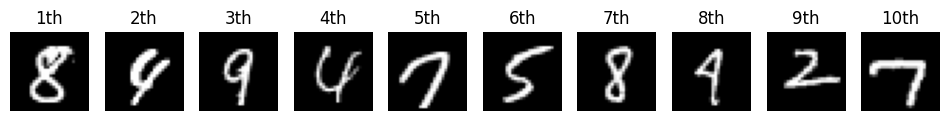

====================== Ensemble Result ======================
1th sample: label = 8, Probability = 0.999920916557312
2th sample: label = 4, Probability = 0.47603491097688677
3th sample: label = 9, Probability = 0.9984368681907654
4th sample: label = 4, Probability = 0.9071509361267089
5th sample: label = 7, Probability = 0.9997574925422669
6th sample: label = 5, Probability = 0.999662971496582
7th sample: label = 8, Probability = 0.9998977541923523
8th sample: label = 4, Probability = 0.6672585308551788
9th sample: label = 2, Probability = 0.9988113403320312
10th sample: label = 7, Probability = 0.9999923467636108

====================== SingleNet Result ======================
1th sample: label = 8, Probability = 0.99966526
2th sample: label = 4, Probability = 0.9175799
3th sample: label = 9, Probability = 0.9992556
4th sample: label = 4, Probability = 0.999041
5th sample: label = 7, Probability = 0.99998116
6th sample: label = 5, Probability = 0.99998736
7th sample: label = 8, Probabi

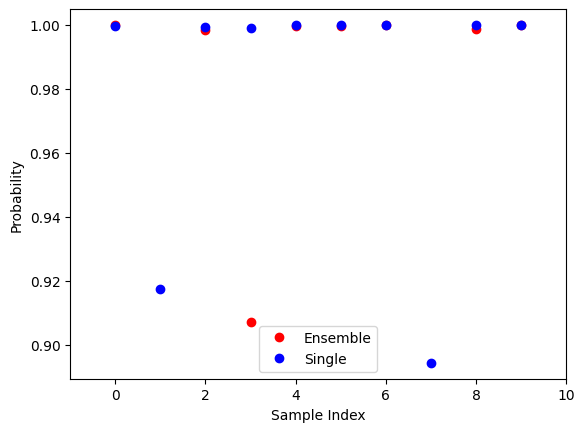

In [23]:
MNIST_sample_index = np.random.choice(train_x.shape[0], 10)

# MNIST plotting
f_Mnist, ax_Mnist = plt.subplots(1, 10, figsize=(12,24))

output_sample     = []
output_sample_one = []

for i, index in enumerate(MNIST_sample_index):
    img_MNIST = np.reshape(train_x[index], (img_size, img_size))
    
    ax_Mnist[i].imshow(img_MNIST, cmap='gray')
    ax_Mnist[i].axis('off')
    ax_Mnist[i].set_title(str(i+1) + 'th')
    
    output_test = np.zeros([1, num_label])
    
    for net_index in range(len(networks)):
        x_temp = np.reshape(train_x[index, :], (1, img_size, img_size, 1))
        y_temp = np.reshape(train_y[index, :], (1, num_label))
        
        loss_temp, prob_temp = sess.run([loss_list[net_index], output_list[net_index]], 
                                         feed_dict = {x_list[net_index]: x_temp, y_list[net_index]: y_temp})
        
        # Add test prediction for get final prediction
        output_test += prob_temp
        
    # Get final test prediction
    prob_temp_final = output_test / len(networks)
    prob_temp_one   = prob_temp
    
    output_sample.append(prob_temp_final)
    output_sample_one.append(prob_temp_one)

plt.show()

print("====================== Ensemble Result ======================")
array_ensemble_MNIST = np.zeros([10])
for i in range(len(output_sample)):

    idx_sample = np.argmax(output_sample[i])
    max_prob = output_sample[i][0, idx_sample]
    array_ensemble_MNIST[i] = max_prob
    
    print(str(i+1) + 'th sample: label = ' + str(idx_sample) + ', Probability = ' + str(max_prob))

print("\n====================== SingleNet Result ======================")
array_single_MNIST = np.zeros([10])
for i in range(len(output_sample_one)):
    
    idx_sample = np.argmax(output_sample_one[i])
    max_prob = output_sample_one[i][0, idx_sample]
    array_single_MNIST[i] = max_prob
    
    print(str(i+1) + 'th sample: label = ' + str(idx_sample) + ', Probability = ' + str(max_prob))
    
plt.figure()
plt.plot(array_ensemble_MNIST, 'or')
plt.plot(array_single_MNIST, 'ob')
plt.xlim([-1, 10])
plt.ylim([np.min(array_single_MNIST) - 0.005, np.max(array_ensemble_MNIST) + 0.005])
plt.xlabel('Sample Index')
plt.ylabel('Probability')
plt.legend(['Ensemble', 'Single'], loc='best')
plt.show()

## Testing with NotMNIST Data

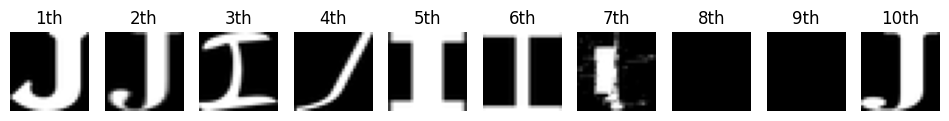

====================== Ensemble Result ======================
1th sample: label = 3, Probability = 0.6938382387161255
2th sample: label = 1, Probability = 0.7801082134246826
3th sample: label = 1, Probability = 0.9895480632781982
4th sample: label = 1, Probability = 0.35808701515197755
5th sample: label = 9, Probability = 0.34813198195770384
6th sample: label = 1, Probability = 0.9989027380943298
7th sample: label = 8, Probability = 0.4007347755134106
8th sample: label = 1, Probability = 0.6025038897991181
9th sample: label = 1, Probability = 0.6025038897991181
10th sample: label = 3, Probability = 0.7082237362861633

====================== SingleNet Result ======================
1th sample: label = 3, Probability = 0.9772495
2th sample: label = 1, Probability = 0.9684873
3th sample: label = 1, Probability = 0.99994445
4th sample: label = 1, Probability = 0.4830927
5th sample: label = 1, Probability = 0.95460415
6th sample: label = 1, Probability = 0.9999949
7th sample: label = 8, Prob

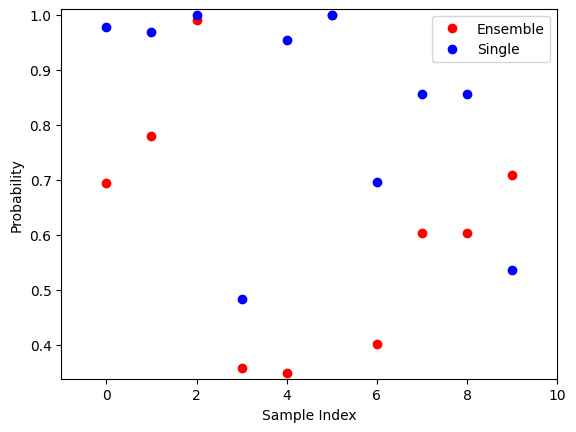

In [24]:
NotMNIST_sample_index = np.random.choice(NotMNIST_x.shape[0], 10)

# MNIST plotting
f_NotMnist, ax_NotMnist = plt.subplots(1, 10, figsize=(12,24))

output_sample     = []
output_sample_one = []

for i, index in enumerate(NotMNIST_sample_index):
    img_NotMNIST = np.reshape(NotMNIST_x[index], (img_size, img_size))
    
    ax_NotMnist[i].imshow(img_NotMNIST, cmap='gray')
    ax_NotMnist[i].axis('off')
    ax_NotMnist[i].set_title(str(i+1) + 'th')
    
    output_test = np.zeros([1, num_label])
    
    for net_index in range(len(networks)):
        x_temp = np.reshape(NotMNIST_x[index, :], (1, img_size, img_size, 1))
        y_temp = np.reshape(NotMNIST_y[index, :], (1, num_label))
        
        loss_temp, prob_temp = sess.run([loss_list[net_index], output_list[net_index]], 
                                         feed_dict = {x_list[net_index]: x_temp, y_list[net_index]: y_temp})
        
        # Add test prediction for get final prediction
        output_test += prob_temp
        
    # Get final test prediction
    prob_temp_final = output_test / len(networks)
    prob_temp_one   = prob_temp

    output_sample.append(prob_temp_final)
    output_sample_one.append(prob_temp_one)

plt.show()

print("====================== Ensemble Result ======================")
array_ensemble_NotMNIST = np.zeros([10])
for i in range(len(output_sample)):
    
    idx_sample = np.argmax(output_sample[i])
    max_prob = output_sample[i][0, idx_sample]
    array_ensemble_NotMNIST[i] = max_prob
    
    print(str(i+1) + 'th sample: label = ' + str(idx_sample) + ', Probability = ' + str(max_prob))

print("\n====================== SingleNet Result ======================")
array_single_NotMNIST = np.zeros([10])
for i in range(len(output_sample_one)):
    
    idx_sample = np.argmax(output_sample_one[i])
    max_prob = output_sample_one[i][0, idx_sample]
    array_single_NotMNIST[i] = max_prob
    
    print(str(i+1) + 'th sample: label = ' + str(idx_sample) + ', Probability = ' + str(max_prob))
    
plt.figure()
plt.plot(array_ensemble_NotMNIST, 'or')
plt.plot(array_single_NotMNIST, 'ob')
plt.xlim([-1, 10])
plt.ylim([np.min(array_ensemble_NotMNIST) - 0.01, np.max(array_single_NotMNIST) + 0.01])
plt.xlabel('Sample Index')
plt.ylabel('Probability')
plt.legend(['Ensemble', 'Single'], loc='best')
plt.show()

Calculating predictions for all datasets...
This may take a few minutes...

Processing Training Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (NotMNIST)...
Processing Testing Data (NotMNIST)...
Processing Combined Testing Data...
Done!

Processing Combined Testing Data...
Done!



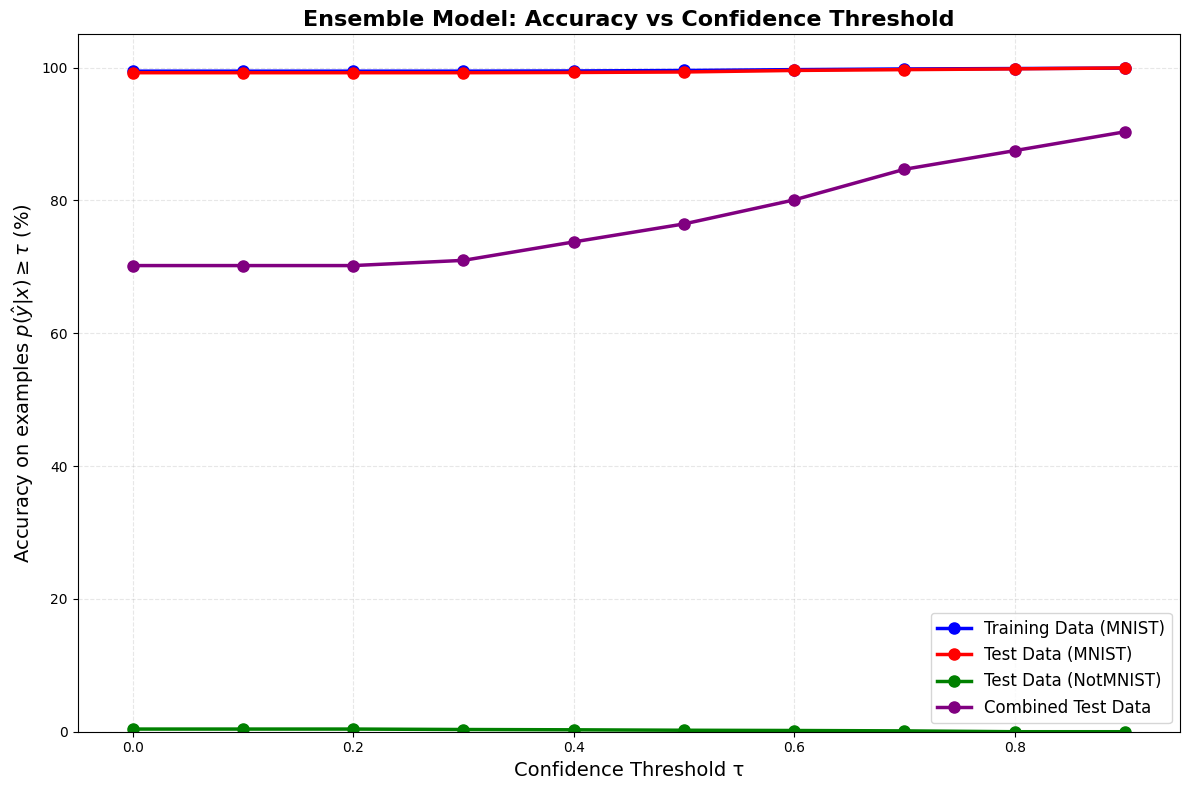


ACCURACY BY CONFIDENCE THRESHOLD
Threshold         Train     Test(MNIST)     Test(NotMNIST)     Combined
--------------------------------------------------------------------------------
0.0            99.45%          99.22%              0.40%       70.18%
             (60000 ex)     ( 9000 ex)        ( 3745 ex)       (12745 ex)
0.1            99.45%          99.22%              0.40%       70.18%
             (60000 ex)     ( 9000 ex)        ( 3745 ex)       (12745 ex)
0.2            99.45%          99.22%              0.40%       70.18%
             (60000 ex)     ( 9000 ex)        ( 3745 ex)       (12745 ex)
0.3            99.45%          99.22%              0.33%       70.97%
             (59997 ex)     ( 9000 ex)        ( 3600 ex)       (12600 ex)
0.4            99.49%          99.26%              0.29%       73.74%
             (59970 ex)     ( 8995 ex)        ( 3124 ex)       (12119 ex)
0.5            99.56%          99.33%              0.22%       76.45%
             (59878 ex)

In [25]:
# Generate Confidence Threshold vs Accuracy Curves using trained ensemble model
# Creates 4 curves:
# 1. Training data (MNIST)
# 2. Testing data (MNIST) 
# 3. Testing data (NotMNIST)
# 4. Combined testing data (MNIST + NotMNIST)

def get_ensemble_predictions_and_accuracy(data_x, data_y, batch_size=100):
    """
    Get ensemble predictions and calculate accuracy for given data
    Returns: predictions (confidence values), labels, correctness
    """
    num_samples = data_x.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    all_confidences = []
    all_correct = []
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, num_samples)
        batch_size_actual = end_idx - start_idx
        
        batch_x = np.zeros([batch_size_actual, img_size, img_size, 1])
        batch_y = np.zeros([batch_size_actual, num_label])
        
        for i in range(batch_size_actual):
            batch_x[i,:,:,:] = np.reshape(data_x[start_idx + i, :], (img_size, img_size, 1))
            batch_y[i,:] = data_y[start_idx + i, :]
        
        # Get ensemble prediction
        output_ensemble = np.zeros([batch_size_actual, num_label])
        
        for net_index in range(len(networks)):
            prob_temp = sess.run(output_list[net_index], 
                                feed_dict={x_list[net_index]: batch_x})
            output_ensemble += prob_temp
        
        # Average predictions across ensemble
        output_ensemble /= len(networks)
        
        # Get max confidence (prediction probability)
        max_confidence = np.max(output_ensemble, axis=1)
        
        # Check if predictions are correct
        pred_labels = np.argmax(output_ensemble, axis=1)
        true_labels = np.argmax(batch_y, axis=1)
        correct = (pred_labels == true_labels)
        
        all_confidences.extend(max_confidence)
        all_correct.extend(correct)
    
    return np.array(all_confidences), np.array(all_correct)


def calculate_accuracy_by_threshold(confidences, correct, thresholds):
    """
    Calculate accuracy for examples with confidence >= threshold
    """
    accuracies = []
    num_examples = []
    
    for tau in thresholds:
        mask = confidences >= tau
        num_filtered = np.sum(mask)
        
        if num_filtered > 0:
            accuracy = np.mean(correct[mask]) * 100
            accuracies.append(accuracy)
            num_examples.append(num_filtered)
        else:
            accuracies.append(np.nan)
            num_examples.append(0)
    
    return np.array(accuracies), np.array(num_examples)


# Define confidence thresholds
thresholds = np.arange(0.0, 1.0, 0.1)

print("Calculating predictions for all datasets...")
print("This may take a few minutes...\n")

# 1. Training data (MNIST)
print("Processing Training Data (MNIST)...")
train_confidences, train_correct = get_ensemble_predictions_and_accuracy(train_x, train_y)
train_accuracies, train_counts = calculate_accuracy_by_threshold(train_confidences, train_correct, thresholds)

# 2. Testing data (MNIST)
print("Processing Testing Data (MNIST)...")
test_confidences, test_correct = get_ensemble_predictions_and_accuracy(test_x, test_y)
test_accuracies, test_counts = calculate_accuracy_by_threshold(test_confidences, test_correct, thresholds)

# 3. Testing data (NotMNIST)
print("Processing Testing Data (NotMNIST)...")
notmnist_confidences, notmnist_correct = get_ensemble_predictions_and_accuracy(NotMNIST_x, NotMNIST_y)
notmnist_accuracies, notmnist_counts = calculate_accuracy_by_threshold(notmnist_confidences, notmnist_correct, thresholds)

# 4. Combined testing data (MNIST + NotMNIST)
print("Processing Combined Testing Data...")
combined_confidences = np.concatenate([test_confidences, notmnist_confidences])
combined_correct = np.concatenate([test_correct, notmnist_correct])
combined_accuracies, combined_counts = calculate_accuracy_by_threshold(combined_confidences, combined_correct, thresholds)

print("Done!\n")

# Create the plot
plt.figure(figsize=(12, 8))

plt.plot(thresholds, train_accuracies, 'o-', color='blue', linewidth=2.5, markersize=8, label='Training Data (MNIST)')
plt.plot(thresholds, test_accuracies, 'o-', color='red', linewidth=2.5, markersize=8, label='Test Data (MNIST)')
plt.plot(thresholds, notmnist_accuracies, 'o-', color='green', linewidth=2.5, markersize=8, label='Test Data (NotMNIST)')
plt.plot(thresholds, combined_accuracies, 'o-', color='purple', linewidth=2.5, markersize=8, label='Combined Test Data')

plt.xlabel('Confidence Threshold τ', fontsize=14)
plt.ylabel('Accuracy on examples $p(\\hat{y}|x) \\geq τ$ (%)', fontsize=14)
plt.title('Ensemble Model: Accuracy vs Confidence Threshold', fontsize=16, fontweight='bold')
plt.xlim([-0.05, 0.95])
plt.ylim([0, 105])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("ACCURACY BY CONFIDENCE THRESHOLD")
print("="*80)
print(f"{'Threshold':<12} {'Train':>10} {'Test(MNIST)':>15} {'Test(NotMNIST)':>18} {'Combined':>12}")
print("-"*80)
for i, tau in enumerate(thresholds):
    print(f"{tau:.1f}          {train_accuracies[i]:>7.2f}%   {test_accuracies[i]:>12.2f}%   {notmnist_accuracies[i]:>15.2f}%   {combined_accuracies[i]:>9.2f}%")
    print(f"             ({train_counts[i]:>5} ex)     ({test_counts[i]:>5} ex)        ({notmnist_counts[i]:>5} ex)       ({combined_counts[i]:>5} ex)")
print("="*80)

## MC Dropout Network Comparison

Now let's compare the standard ensemble with MC Dropout. MC Dropout uses a single network with dropout (rate=0.1) after each non-linearity and performs multiple forward passes with dropout enabled during inference to estimate uncertainty.

In [26]:
# Initialize and train MC Dropout network
# Reset graph and create MC Dropout network
tf.reset_default_graph()

# Create MC Dropout network
mc_dropout_network = 'mc_dropout_net'
x_mc, y_mc, output_mc, loss_mc, train_mc, train_vars_mc, is_training_mc = get_network_mc_dropout(mc_dropout_network, dropout_rate=0.1)

# Close previous session if exists and create new session for MC Dropout
try:
    sess.close()
except:
    pass

config_mc = tf.ConfigProto()
config_mc.gpu_options.per_process_gpu_memory_fraction = gpu_fraction

sess_mc = tf.InteractiveSession(config=config_mc)
sess_mc.run(tf.global_variables_initializer())

print("Training MC Dropout Network...")
print("Using dropout rate of 0.1 after each non-linearity (ReLU)")
print("="*60)

# Training parameters
num_iter_mc = 800
num_print_mc = 100

loss_check_mc = 0
acc_check_mc = 0
acc_check_test_mc = 0

for iter in range(num_iter_mc):
    # Making batches
    batch_x, batch_y = making_batch(train_x.shape[0], batch_size, train_x, train_y)
    batch_x_test, batch_y_test = making_batch(test_x.shape[0], 10, test_x, test_y)
    
    # Training with dropout enabled
    _, loss_val, prob_val = sess_mc.run([train_mc, loss_mc, output_mc], 
                                        feed_dict={x_mc: batch_x, y_mc: batch_y, is_training_mc: True})
    
    # Testing with dropout enabled (MC Dropout style)
    loss_test_val, prob_test_val = sess_mc.run([loss_mc, output_mc], 
                                                feed_dict={x_mc: batch_x_test, y_mc: batch_y_test, is_training_mc: True})
    
    # Calculate accuracies
    acc_train = get_accuracy(prob_val, batch_y)
    acc_test = get_accuracy(prob_test_val, batch_y_test)
    
    loss_check_mc += loss_val
    acc_check_mc += acc_train
    acc_check_test_mc += acc_test
    
    if iter % num_print_mc == 0 and iter != 0:
        print(f"Iteration {iter:5d}: Loss={loss_check_mc/num_print_mc:.6f}, "
              f"Train Acc={acc_check_mc/num_print_mc:.4f}, Test Acc={acc_check_test_mc/num_print_mc:.4f}")
        
        loss_check_mc = 0
        acc_check_mc = 0
        acc_check_test_mc = 0

print("\nMC Dropout Training Complete!")
print("="*60)

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.
Training MC Dropout Network...
Using dropout rate of 0.1 after each non-linearity (ReLU)
Training MC Dropout Network...
Using dropout rate of 0.1 after each non-linearity (ReLU)
Iteration   100: Loss=0.032083, Train Acc=0.7675, Test Acc=0.7750
Iteration   100: Loss=0.032083, Train Acc=0.7675, Test Acc=0.7750
Iteration   200: Loss=0.006324, Train Acc=0.9587, Test Acc=0.9500
Iteration   200: Loss=0.006324, Train Acc=0.9587, Test Acc=0.9500
Iteration   300: Loss=0.004084, Train Acc=0.9734, Test Acc=0.9780
Iteration   300: Loss=0.004084, Train Acc=0.9734, Test Acc=0.9780
Iteration   400: Loss=0.003058, Train Acc=0.9800, Test Acc=0.9770

In [27]:
# Generate MC Dropout predictions with multiple stochastic forward passes
def get_mc_dropout_predictions(data_x, data_y, num_mc_samples=10, batch_size=100):
    """
    Get MC Dropout predictions using multiple stochastic forward passes
    num_mc_samples: number of forward passes with dropout enabled
    """
    num_samples = data_x.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    all_confidences = []
    all_correct = []
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, num_samples)
        batch_size_actual = end_idx - start_idx
        
        batch_x = np.zeros([batch_size_actual, img_size, img_size, 1])
        batch_y = np.zeros([batch_size_actual, num_label])
        
        for i in range(batch_size_actual):
            batch_x[i,:,:,:] = np.reshape(data_x[start_idx + i, :], (img_size, img_size, 1))
            batch_y[i,:] = data_y[start_idx + i, :]
        
        # Perform multiple forward passes with dropout enabled
        mc_predictions = np.zeros([batch_size_actual, num_label])
        
        for mc_iter in range(num_mc_samples):
            prob_temp = sess_mc.run(output_mc, 
                                    feed_dict={x_mc: batch_x, is_training_mc: True})
            mc_predictions += prob_temp
        
        # Average predictions across MC samples
        mc_predictions /= num_mc_samples
        
        # Get max confidence
        max_confidence = np.max(mc_predictions, axis=1)
        
        # Check correctness
        pred_labels = np.argmax(mc_predictions, axis=1)
        true_labels = np.argmax(batch_y, axis=1)
        correct = (pred_labels == true_labels)
        
        all_confidences.extend(max_confidence)
        all_correct.extend(correct)
    
    return np.array(all_confidences), np.array(all_correct)


# Generate predictions for all datasets using MC Dropout
print("Generating MC Dropout predictions (10 stochastic forward passes)...")
print("="*60)

# Training data
print("Processing Training Data (MNIST) with MC Dropout...")
mc_train_confidences, mc_train_correct = get_mc_dropout_predictions(train_x, train_y, num_mc_samples=10)
mc_train_accuracies, mc_train_counts = calculate_accuracy_by_threshold(mc_train_confidences, mc_train_correct, thresholds)

# Testing data (MNIST)
print("Processing Testing Data (MNIST) with MC Dropout...")
mc_test_confidences, mc_test_correct = get_mc_dropout_predictions(test_x, test_y, num_mc_samples=10)
mc_test_accuracies, mc_test_counts = calculate_accuracy_by_threshold(mc_test_confidences, mc_test_correct, thresholds)

# Testing data (NotMNIST)
print("Processing Testing Data (NotMNIST) with MC Dropout...")
mc_notmnist_confidences, mc_notmnist_correct = get_mc_dropout_predictions(NotMNIST_x, NotMNIST_y, num_mc_samples=10)
mc_notmnist_accuracies, mc_notmnist_counts = calculate_accuracy_by_threshold(mc_notmnist_confidences, mc_notmnist_correct, thresholds)

# Combined testing data
print("Processing Combined Testing Data with MC Dropout...")
mc_combined_confidences = np.concatenate([mc_test_confidences, mc_notmnist_confidences])
mc_combined_correct = np.concatenate([mc_test_correct, mc_notmnist_correct])
mc_combined_accuracies, mc_combined_counts = calculate_accuracy_by_threshold(mc_combined_confidences, mc_combined_correct, thresholds)

print("Done!")
print("="*60)

Generating MC Dropout predictions (10 stochastic forward passes)...
Processing Training Data (MNIST) with MC Dropout...
Processing Testing Data (MNIST) with MC Dropout...
Processing Testing Data (MNIST) with MC Dropout...
Processing Testing Data (NotMNIST) with MC Dropout...
Processing Testing Data (NotMNIST) with MC Dropout...
Processing Combined Testing Data with MC Dropout...
Done!
Processing Combined Testing Data with MC Dropout...
Done!


## Ensemble + R (Random Direction Augmentation)

Train ensemble networks with random direction augmentation as a baseline to compare with adversarial training.

In [28]:
# Initialize Ensemble + R Networks with Enhanced Data Augmentation
# Reset graph for Ensemble + R
tf.reset_default_graph()

# Close previous session if exists
try:
    sess_mc.close()
except:
    pass

# Parameters for improved random augmentation
random_epsilon = 0.02  # Smaller Gaussian noise for better quality
rotation_range = 15  # degrees
shift_range = 0.1  # 10% of image size
scale_range = 0.1  # 10% zoom in/out
label_smoothing = 0.1  # For better generalization

# Create networks for Ensemble + R
networks_r = ['network_r1', 'network_r2', 'network_r3', 'network_r4', 'network_r5']

x_list_r = []
y_list_r = []
output_list_r = []
loss_list_r = []
train_list_r = []
train_var_list_r = []

# Train each ensemble network with enhanced augmentation
for i in range(len(networks_r)):
    x_image, y_label, output, loss, train_opt, train_vars = get_network(networks_r[i])

    x_list_r.append(x_image)
    y_list_r.append(y_label)
    output_list_r.append(output)
    loss_list_r.append(loss)
    train_list_r.append(train_opt)
    train_var_list_r.append(train_vars)

# Create Session for Ensemble + R
config_r = tf.ConfigProto()
config_r.gpu_options.per_process_gpu_memory_fraction = gpu_fraction

sess_r = tf.InteractiveSession(config=config_r)
sess_r.run(tf.global_variables_initializer())

print("Ensemble + R (Enhanced Data Augmentation) initialized")
print(f"Number of networks: {len(networks_r)}")
print(f"Augmentation: rotation±{rotation_range}°, shift±{shift_range*100}%, scale±{scale_range*100}%, noise σ={random_epsilon}")
print(f"Label smoothing: {label_smoothing}")
print("="*60)

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.
Ensemble + R (Enhanced Data Augmentation) initialized
Number of networks: 5
Augmentation: rotation±15°, shift±10.0%, scale±10.0%, noise σ=0.02
Label smoothing: 0.1
Ensemble + R (Enhanced Data Augmentation) initialized
Number of networks: 5
Augmentation: rotation±15°, shift±10.0%, scale±10.0%, noise σ=0.02
Label smoothing: 0.1


In [29]:
# Training Ensemble + R with Enhanced Data Augmentation
print("Training Ensemble + R with Enhanced Data Augmentation...")
print("Using rotation, translation, scaling, and Gaussian noise")
print("="*60)

# Initialize tracking variables
loss_check_r = np.zeros(len(networks_r))
acc_check_r = np.zeros(len(networks_r))
acc_check_test_r = np.zeros(len(networks_r))
acc_check_test_final_r = 0

# Set parameters for printing and testing
num_print = 100
test_size = 10

train_data_num = train_x.shape[0]
test_data_num = test_x.shape[0]

# Train 50% longer than standard ensemble for better convergence
# num_iter_r = int(num_iter * 1.5)
num_iter_r = num_iter 

for iter in range(num_iter_r):
    output_temp = np.zeros([test_size, num_label])

    # Making batches(testing) - no augmentation for test
    batch_x_test, batch_y_test = making_batch(test_data_num, test_size, test_x, test_y)
        
    for i in range(len(networks_r)):
        # Making batches(training)
        batch_x, batch_y = making_batch(train_data_num, batch_size, train_x, train_y)
        
        # Apply Enhanced Data Augmentation
        batch_x_augmented = np.zeros_like(batch_x)
        batch_y_augmented = batch_y.copy()
        
        # Apply label smoothing for better generalization
        batch_y_augmented = batch_y_augmented * (1 - label_smoothing) + label_smoothing / num_label
        
        for j in range(batch_x.shape[0]):
            img = batch_x[j].reshape(img_size, img_size)
            
            # Random rotation
            angle = np.random.uniform(-rotation_range, rotation_range)
            center = (img_size // 2, img_size // 2)
            M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
            img = cv2.warpAffine(img, M_rot, (img_size, img_size), borderValue=0)
            
            # Random translation
            shift_x = np.random.uniform(-shift_range, shift_range) * img_size
            shift_y = np.random.uniform(-shift_range, shift_range) * img_size
            M_trans = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
            img = cv2.warpAffine(img, M_trans, (img_size, img_size), borderValue=0)
            
            # Random scaling (zoom)
            scale = 1.0 + np.random.uniform(-scale_range, scale_range)
            M_scale = cv2.getRotationMatrix2D(center, 0, scale)
            img = cv2.warpAffine(img, M_scale, (img_size, img_size), borderValue=0)
            
            # Add Gaussian noise
            noise = np.random.normal(0, random_epsilon, img.shape)
            img = img + noise
            
            # Clip to valid range
            img = np.clip(img, 0.0, 1.0)
            
            batch_x_augmented[j] = img.reshape(img_size, img_size, 1)
       
        # Training with augmented data and smoothed labels
        _, loss, prob = sess_r.run([train_list_r[i], loss_list_r[i], output_list_r[i]], 
                                    feed_dict={x_list_r[i]: batch_x_augmented, y_list_r[i]: batch_y_augmented})
        
        # Testing (without augmentation)
        loss_test, prob_test = sess_r.run([loss_list_r[i], output_list_r[i]], 
                                          feed_dict={x_list_r[i]: batch_x_test, y_list_r[i]: batch_y_test})
        
        # Add test prediction for get final prediction
        output_temp += prob_test
        
        # Calculate Accuracy (Training)
        acc_training = get_accuracy(prob, batch_y)
 
        # Calculate Accuracy (testing)
        acc_testing = get_accuracy(prob_test, batch_y_test)
                
        # Get accuracy and loss for each network
        acc_check_r[i] += acc_training
        acc_check_test_r[i] += acc_testing
        loss_check_r[i] += loss
    
    # Get final test prediction (ensemble)
    prob_test_final = output_temp / len(networks_r)
    
    # Calculate Accuracy (Testing final)
    acc_testing_final = get_accuracy(prob_test_final, batch_y_test)
    acc_check_test_final_r += acc_testing_final
    
    if iter % num_print == 0 and iter != 0:
        print(f'------------------------- Iteration: {iter}/{num_iter_r} -------------------------')
        print('Average Loss(Brier score): ' + str(loss_check_r / num_print))
        print('Training Accuracy: ' + str(acc_check_r / num_print))
        print('Testing Accuracy: ' + str(acc_check_test_r / num_print))
        print('Final Testing Accuracy: ' + str(acc_check_test_final_r / num_print))
        print('\n')
        
        loss_check_r = np.zeros(len(networks_r))
        acc_check_r = np.zeros(len(networks_r))
        acc_check_test_r = np.zeros(len(networks_r))
        acc_check_test_final_r = 0

print("Ensemble + R Training Complete!")
print("="*60)

Training Ensemble + R with Enhanced Data Augmentation...
Using rotation, translation, scaling, and Gaussian noise
------------------------- Iteration: 100/800 -------------------------
Average Loss(Brier score): [0.03819008 0.03993977 0.03835482 0.04195138 0.04190955]
Training Accuracy: [0.63539062 0.61148437 0.63335937 0.59683594 0.59429687]
Testing Accuracy: [0.741 0.717 0.725 0.663 0.694]
Final Testing Accuracy: 0.7569999999999999


------------------------- Iteration: 100/800 -------------------------
Average Loss(Brier score): [0.03819008 0.03993977 0.03835482 0.04195138 0.04190955]
Training Accuracy: [0.63539062 0.61148437 0.63335937 0.59683594 0.59429687]
Testing Accuracy: [0.741 0.717 0.725 0.663 0.694]
Final Testing Accuracy: 0.7569999999999999


------------------------- Iteration: 200/800 -------------------------
Average Loss(Brier score): [0.00887449 0.0087517  0.00862346 0.00902011 0.00909635]
Training Accuracy: [0.93363281 0.93332031 0.93335937 0.93171875 0.93089844]
Tes

In [30]:
# Generate Ensemble + R predictions for all datasets
def get_ensemble_r_predictions(data_x, data_y, batch_size=100):
    """
    Get Ensemble + R predictions
    """
    num_samples = data_x.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    all_confidences = []
    all_correct = []
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, num_samples)
        batch_size_actual = end_idx - start_idx
        
        batch_x = np.zeros([batch_size_actual, img_size, img_size, 1])
        batch_y = np.zeros([batch_size_actual, num_label])
        
        for i in range(batch_size_actual):
            batch_x[i,:,:,:] = np.reshape(data_x[start_idx + i, :], (img_size, img_size, 1))
            batch_y[i,:] = data_y[start_idx + i, :]
        
        # Get ensemble prediction (no augmentation at inference)
        output_ensemble = np.zeros([batch_size_actual, num_label])
        
        for net_index in range(len(networks_r)):
            prob_temp = sess_r.run(output_list_r[net_index], 
                                   feed_dict={x_list_r[net_index]: batch_x})
            output_ensemble += prob_temp
        
        # Average predictions across ensemble
        output_ensemble /= len(networks_r)
        
        # Get max confidence
        max_confidence = np.max(output_ensemble, axis=1)
        
        # Check correctness
        pred_labels = np.argmax(output_ensemble, axis=1)
        true_labels = np.argmax(batch_y, axis=1)
        correct = (pred_labels == true_labels)
        
        all_confidences.extend(max_confidence)
        all_correct.extend(correct)
    
    return np.array(all_confidences), np.array(all_correct)


print("Generating Ensemble + R predictions for all datasets...")
print("="*60)

# 1. Training data (MNIST)
print("Processing Training Data (MNIST)...")
ensemble_r_train_confidences, ensemble_r_train_correct = get_ensemble_r_predictions(train_x, train_y)
ensemble_r_train_accuracies, ensemble_r_train_counts = calculate_accuracy_by_threshold(
    ensemble_r_train_confidences, ensemble_r_train_correct, thresholds)

# 2. Testing data (MNIST)
print("Processing Testing Data (MNIST)...")
ensemble_r_test_confidences, ensemble_r_test_correct = get_ensemble_r_predictions(test_x, test_y)
ensemble_r_test_accuracies, ensemble_r_test_counts = calculate_accuracy_by_threshold(
    ensemble_r_test_confidences, ensemble_r_test_correct, thresholds)

# 3. Testing data (NotMNIST)
print("Processing Testing Data (NotMNIST)...")
ensemble_r_notmnist_confidences, ensemble_r_notmnist_correct = get_ensemble_r_predictions(NotMNIST_x, NotMNIST_y)
ensemble_r_notmnist_accuracies, ensemble_r_notmnist_counts = calculate_accuracy_by_threshold(
    ensemble_r_notmnist_confidences, ensemble_r_notmnist_correct, thresholds)

# 4. Combined testing data (MNIST + NotMNIST)
print("Processing Combined Testing Data...")
ensemble_r_combined_confidences = np.concatenate([ensemble_r_test_confidences, ensemble_r_notmnist_confidences])
ensemble_r_combined_correct = np.concatenate([ensemble_r_test_correct, ensemble_r_notmnist_correct])
ensemble_r_combined_accuracies, ensemble_r_combined_counts = calculate_accuracy_by_threshold(
    ensemble_r_combined_confidences, ensemble_r_combined_correct, thresholds)

print("Done!")
print("="*60)

Generating Ensemble + R predictions for all datasets...
Processing Training Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (NotMNIST)...
Processing Testing Data (NotMNIST)...
Processing Combined Testing Data...
Done!
Processing Combined Testing Data...
Done!


## Ensemble + AT (Adversarial Training)

Train ensemble networks with adversarial training using Fast Gradient Sign Method (FGSM) to generate adversarial examples that maximize the loss.

In [31]:
# Initialize Ensemble + AT Networks with Adversarial Training
# Reset graph for Ensemble + AT
tf.reset_default_graph()

# Close previous session if exists
try:
    sess_r.close()
except:
    pass

# Parameters for adversarial training
adversarial_epsilon = 0.01  # Magnitude of adversarial perturbation (e.g., 1% of input range)

# Create networks for Ensemble + AT
networks_at = ['network_at1', 'network_at2', 'network_at3', 'network_at4', 'network_at5']

x_list_at = []
y_list_at = []
output_list_at = []
loss_list_at = []
train_list_at = []
train_var_list_at = []
gradients_list_at = []

# Build networks and compute gradients for FGSM
for i in range(len(networks_at)):
    x_image, y_label, output, loss, train_opt, train_vars = get_network(networks_at[i])
    
    # Compute gradient of loss with respect to input (for FGSM)
    gradients = tf.gradients(loss, x_image)[0]
    
    x_list_at.append(x_image)
    y_list_at.append(y_label)
    output_list_at.append(output)
    loss_list_at.append(loss)
    train_list_at.append(train_opt)
    train_var_list_at.append(train_vars)
    gradients_list_at.append(gradients)

# Create Session for Ensemble + AT
config_at = tf.ConfigProto()
config_at.gpu_options.per_process_gpu_memory_fraction = gpu_fraction

sess_at = tf.InteractiveSession(config=config_at)
sess_at.run(tf.global_variables_initializer())

print("Ensemble + AT (Adversarial Training with FGSM) initialized")
print(f"Number of networks: {len(networks_at)}")
print(f"Adversarial perturbation epsilon: {adversarial_epsilon}")
print("Using Fast Gradient Sign Method (FGSM)")
print("="*60)

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.
Ensemble + AT (Adversarial Training with FGSM) initialized
Number of networks: 5
Adversarial perturbation epsilon: 0.01
Using Fast Gradient Sign Method (FGSM)
Ensemble + AT (Adversarial Training with FGSM) initialized
Number of networks: 5
Adversarial perturbation epsilon: 0.01
Using Fast Gradient Sign Method (FGSM)


In [32]:
# Training Ensemble + AT with Adversarial Training (FGSM)
print("Training Ensemble + AT with Adversarial Training...")
print("Using Fast Gradient Sign Method (FGSM) to generate adversarial examples")
print("="*60)

# Initialize tracking variables
loss_check_at = np.zeros(len(networks_at))
acc_check_at = np.zeros(len(networks_at))
acc_check_test_at = np.zeros(len(networks_at))
acc_check_test_final_at = 0

# Set parameters for printing and testing
num_print = 100
test_size = 10

train_data_num = train_x.shape[0]
test_data_num = test_x.shape[0]

for iter in range(num_iter):
    output_temp = np.zeros([test_size, num_label])

    # Making batches(testing) - no augmentation for test
    batch_x_test, batch_y_test = making_batch(test_data_num, test_size, test_x, test_y)
        
    for i in range(len(networks_at)):
        # Making batches(training)
        batch_x, batch_y = making_batch(train_data_num, batch_size, train_x, train_y)
        
        # Generate adversarial examples using FGSM
        # Step 1: Compute gradients of loss w.r.t. input
        grads = sess_at.run(gradients_list_at[i], 
                           feed_dict={x_list_at[i]: batch_x, y_list_at[i]: batch_y})
        
        # Step 2: Apply FGSM: x' = x + epsilon * sign(gradient)
        adversarial_perturbation = adversarial_epsilon * np.sign(grads)
        batch_x_adversarial = batch_x + adversarial_perturbation
        
        # Clip to valid image range [0, 1]
        batch_x_adversarial = np.clip(batch_x_adversarial, 0.0, 1.0)
        
        # Step 3: Train on both original and adversarial examples
        # Train on original data
        _, loss_orig, prob_orig = sess_at.run([train_list_at[i], loss_list_at[i], output_list_at[i]], 
                                              feed_dict={x_list_at[i]: batch_x, y_list_at[i]: batch_y})
        
        # Train on adversarial data
        _, loss_adv, prob_adv = sess_at.run([train_list_at[i], loss_list_at[i], output_list_at[i]], 
                                            feed_dict={x_list_at[i]: batch_x_adversarial, y_list_at[i]: batch_y})
        
        # Average loss and predictions
        loss = (loss_orig + loss_adv) / 2.0
        prob = (prob_orig + prob_adv) / 2.0
        
        # Testing (without adversarial perturbation)
        loss_test, prob_test = sess_at.run([loss_list_at[i], output_list_at[i]], 
                                           feed_dict={x_list_at[i]: batch_x_test, y_list_at[i]: batch_y_test})
        
        # Add test prediction for ensemble
        output_temp += prob_test
        
        # Calculate Accuracy (Training - using original data accuracy)
        acc_training = get_accuracy(prob_orig, batch_y)
 
        # Calculate Accuracy (testing)
        acc_testing = get_accuracy(prob_test, batch_y_test)
                
        # Get accuracy and loss for each network
        acc_check_at[i] += acc_training
        acc_check_test_at[i] += acc_testing
        loss_check_at[i] += loss
    
    # Get final test prediction (ensemble)
    prob_test_final = output_temp / len(networks_at)
    
    # Calculate Accuracy (Testing final)
    acc_testing_final = get_accuracy(prob_test_final, batch_y_test)
    acc_check_test_final_at += acc_testing_final
    
    if iter % num_print == 0 and iter != 0:
        print(('-------------------------') + ' Iteration: ' + str(iter) + ' -------------------------')
        print('Average Loss(Brier score): ' + str(loss_check_at / num_print))
        print('Training Accuracy: ' + str(acc_check_at / num_print))
        print('Testing Accuracy: ' + str(acc_check_test_at / num_print))
        print('Final Testing Accuracy: ' + str(acc_check_test_final_at / num_print))
        print('\n')
        
        loss_check_at = np.zeros(len(networks_at))
        acc_check_at = np.zeros(len(networks_at))
        acc_check_test_at = np.zeros(len(networks_at))
        acc_check_test_final_at = 0

print("Ensemble + AT Training Complete!")
print("="*60)

Training Ensemble + AT with Adversarial Training...
Using Fast Gradient Sign Method (FGSM) to generate adversarial examples
------------------------- Iteration: 100 -------------------------
Average Loss(Brier score): [0.02059393 0.01999255 0.01761569 0.01763027 0.01976675]
Training Accuracy: [0.85761719 0.86105469 0.88597656 0.88257812 0.8590625 ]
Testing Accuracy: [0.859 0.877 0.896 0.88  0.867]
Final Testing Accuracy: 0.897


------------------------- Iteration: 100 -------------------------
Average Loss(Brier score): [0.02059393 0.01999255 0.01761569 0.01763027 0.01976675]
Training Accuracy: [0.85761719 0.86105469 0.88597656 0.88257812 0.8590625 ]
Testing Accuracy: [0.859 0.877 0.896 0.88  0.867]
Final Testing Accuracy: 0.897


------------------------- Iteration: 200 -------------------------
Average Loss(Brier score): [0.00406053 0.00466929 0.00412871 0.00456175 0.00442511]
Training Accuracy: [0.97445313 0.97066406 0.97410156 0.97140625 0.97085937]
Testing Accuracy: [0.977 0.975 

In [33]:
# Generate Ensemble + AT predictions for all datasets
def get_ensemble_at_predictions(data_x, data_y, batch_size=100):
    """
    Get Ensemble + AT predictions
    """
    num_samples = data_x.shape[0]
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    all_confidences = []
    all_correct = []
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, num_samples)
        batch_size_actual = end_idx - start_idx
        
        batch_x = np.zeros([batch_size_actual, img_size, img_size, 1])
        batch_y = np.zeros([batch_size_actual, num_label])
        
        for i in range(batch_size_actual):
            batch_x[i,:,:,:] = np.reshape(data_x[start_idx + i, :], (img_size, img_size, 1))
            batch_y[i,:] = data_y[start_idx + i, :]
        
        # Get ensemble prediction (no adversarial perturbation at inference)
        output_ensemble = np.zeros([batch_size_actual, num_label])
        
        for net_index in range(len(networks_at)):
            prob_temp = sess_at.run(output_list_at[net_index], 
                                    feed_dict={x_list_at[net_index]: batch_x})
            output_ensemble += prob_temp
        
        # Average predictions across ensemble
        output_ensemble /= len(networks_at)
        
        # Get max confidence
        max_confidence = np.max(output_ensemble, axis=1)
        
        # Check correctness
        pred_labels = np.argmax(output_ensemble, axis=1)
        true_labels = np.argmax(batch_y, axis=1)
        correct = (pred_labels == true_labels)
        
        all_confidences.extend(max_confidence)
        all_correct.extend(correct)
    
    return np.array(all_confidences), np.array(all_correct)


print("Generating Ensemble + AT predictions for all datasets...")
print("="*60)

# 1. Training data (MNIST)
print("Processing Training Data (MNIST)...")
ensemble_at_train_confidences, ensemble_at_train_correct = get_ensemble_at_predictions(train_x, train_y)
ensemble_at_train_accuracies, ensemble_at_train_counts = calculate_accuracy_by_threshold(
    ensemble_at_train_confidences, ensemble_at_train_correct, thresholds)

# 2. Testing data (MNIST)
print("Processing Testing Data (MNIST)...")
ensemble_at_test_confidences, ensemble_at_test_correct = get_ensemble_at_predictions(test_x, test_y)
ensemble_at_test_accuracies, ensemble_at_test_counts = calculate_accuracy_by_threshold(
    ensemble_at_test_confidences, ensemble_at_test_correct, thresholds)

# 3. Testing data (NotMNIST)
print("Processing Testing Data (NotMNIST)...")
ensemble_at_notmnist_confidences, ensemble_at_notmnist_correct = get_ensemble_at_predictions(NotMNIST_x, NotMNIST_y)
ensemble_at_notmnist_accuracies, ensemble_at_notmnist_counts = calculate_accuracy_by_threshold(
    ensemble_at_notmnist_confidences, ensemble_at_notmnist_correct, thresholds)

# 4. Combined testing data (MNIST + NotMNIST)
print("Processing Combined Testing Data...")
ensemble_at_combined_confidences = np.concatenate([ensemble_at_test_confidences, ensemble_at_notmnist_confidences])
ensemble_at_combined_correct = np.concatenate([ensemble_at_test_correct, ensemble_at_notmnist_correct])
ensemble_at_combined_accuracies, ensemble_at_combined_counts = calculate_accuracy_by_threshold(
    ensemble_at_combined_confidences, ensemble_at_combined_correct, thresholds)

print("Done!")
print("="*60)

Generating Ensemble + AT predictions for all datasets...
Processing Training Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (MNIST)...
Processing Testing Data (NotMNIST)...
Processing Testing Data (NotMNIST)...
Processing Combined Testing Data...
Done!
Processing Combined Testing Data...
Done!


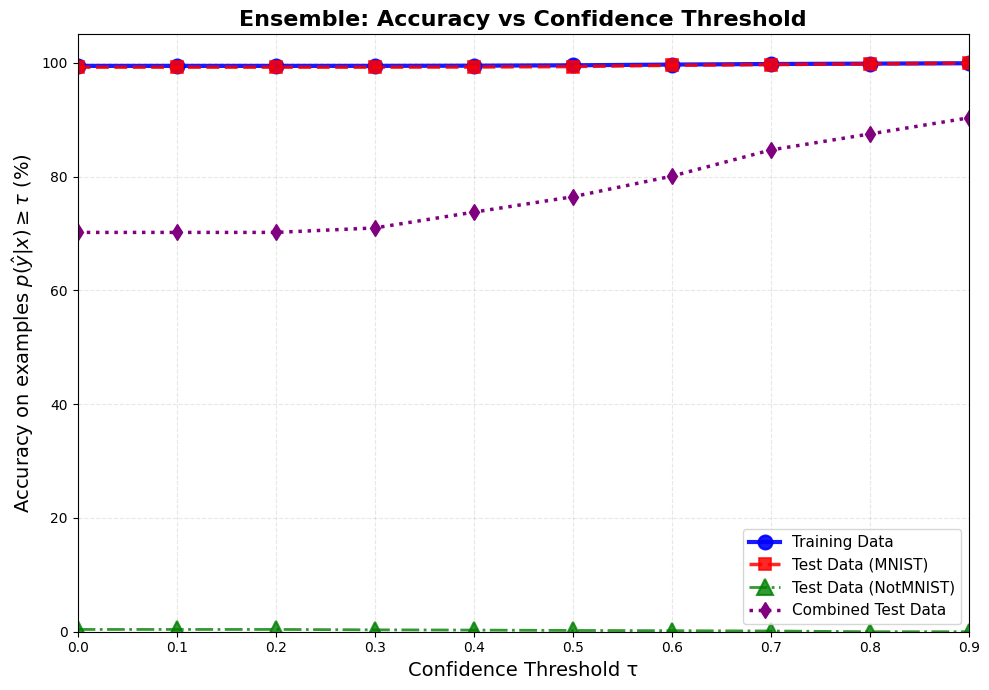


Ensemble - Statistics Summary:
  Training Data:          99.92% at τ=0.9
  Test (MNIST):           99.94% at τ=0.9
  Test (NotMNIST):        0.00% at τ=0.9
  Combined:               90.33% at τ=0.9
------------------------------------------------------------


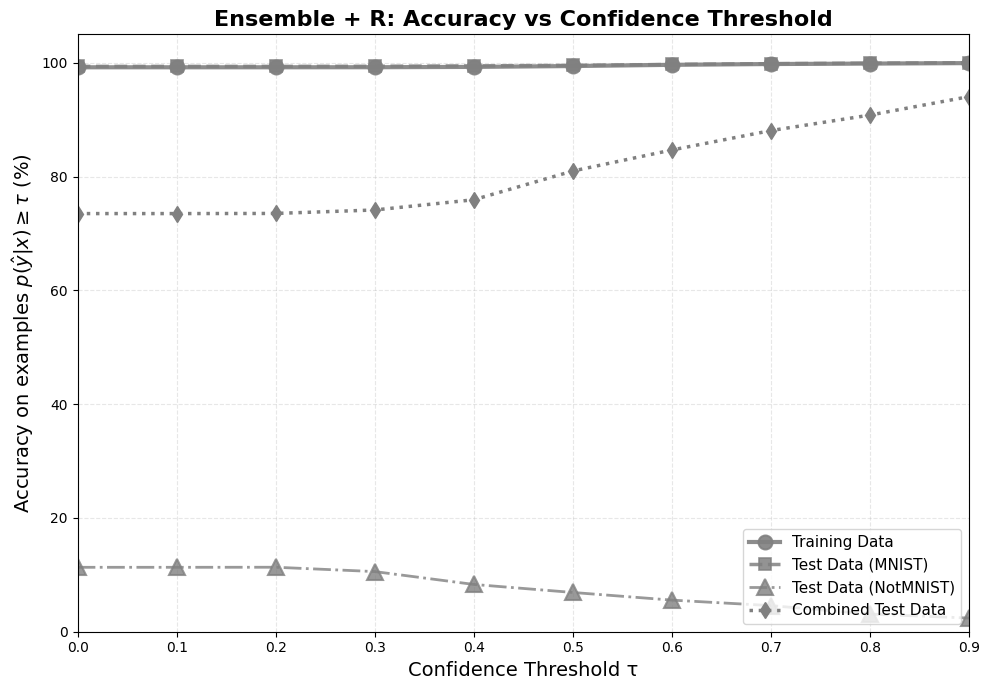


Ensemble + R - Statistics Summary:
  Training Data:          99.94% at τ=0.9
  Test (MNIST):           100.00% at τ=0.9
  Test (NotMNIST):        2.40% at τ=0.9
  Combined:               94.05% at τ=0.9
------------------------------------------------------------


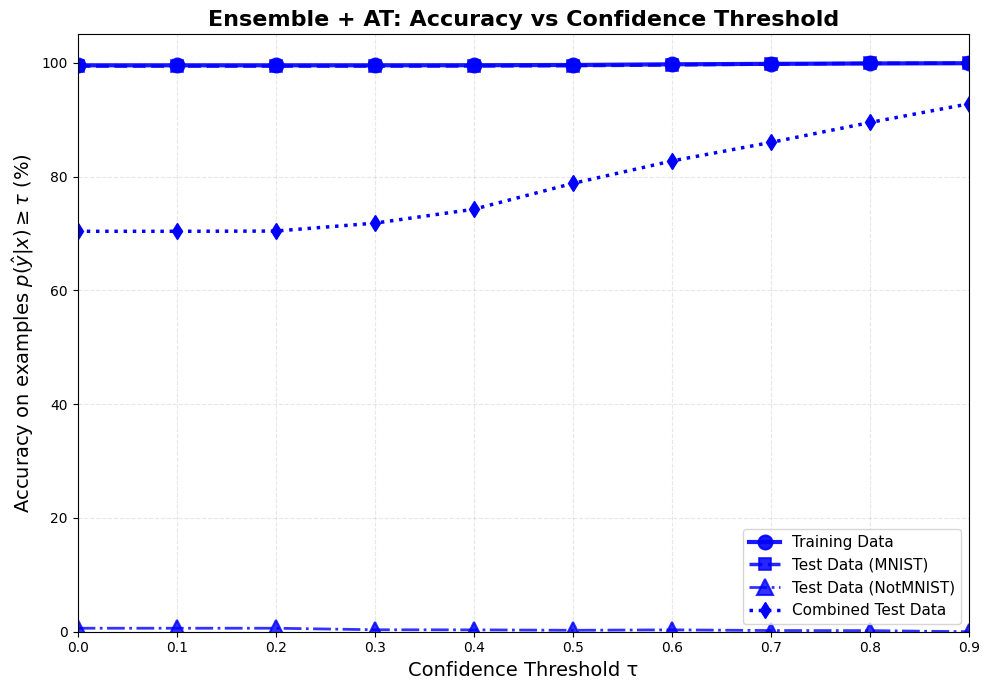


Ensemble + AT - Statistics Summary:
  Training Data:          99.92% at τ=0.9
  Test (MNIST):           99.93% at τ=0.9
  Test (NotMNIST):        0.00% at τ=0.9
  Combined:               92.79% at τ=0.9
------------------------------------------------------------


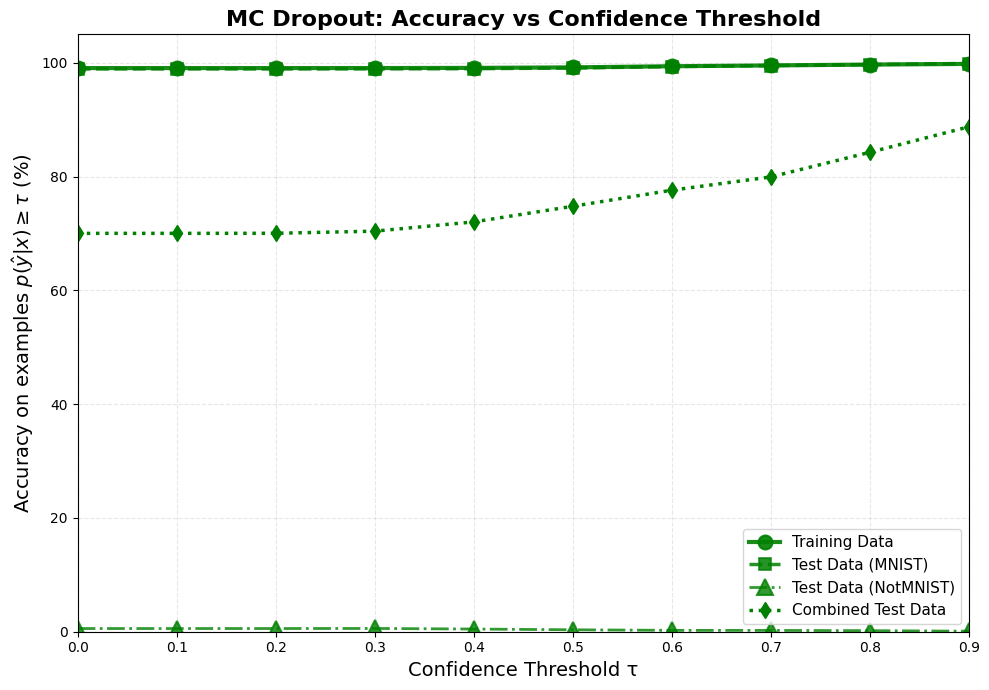


MC Dropout - Statistics Summary:
  Training Data:          99.80% at τ=0.9
  Test (MNIST):           99.87% at τ=0.9
  Test (NotMNIST):        0.09% at τ=0.9
  Combined:               88.75% at τ=0.9
------------------------------------------------------------

COMPARISON: ENSEMBLE vs MC DROPOUT
Dataset                   Method          Threshold    Accuracy     # Examples
----------------------------------------------------------------------------------------------------
Training (MNIST)          Ensemble        0.0          99.45        60000
                          MC Dropout      0.0          99.07        60000
                          Ensemble        0.1          99.45        60000
                          MC Dropout      0.1          99.07        60000
                          Ensemble        0.2          99.45        60000
                          MC Dropout      0.2          99.07        60000
                          Ensemble        0.3          99.45        59997
    

In [34]:
# Generate 4 comparison plots - one for each model
# Each plot shows 4 curves: Training, Test (MNIST), Test (NotMNIST), Combined

# Model configurations (using actual trained models)
models = [
    {
        'name': 'Ensemble',
        'train': train_accuracies,
        'test_mnist': test_accuracies,
        'test_notmnist': notmnist_accuracies,
        'combined': combined_accuracies,
        'color_train': 'blue',
        'color_test_mnist': 'red',
        'color_test_notmnist': 'green',
        'color_combined': 'purple'
    },
    {
        'name': 'Ensemble + R',
        'train': ensemble_r_train_accuracies,
        'test_mnist': ensemble_r_test_accuracies,
        'test_notmnist': ensemble_r_notmnist_accuracies,
        'combined': ensemble_r_combined_accuracies,
        'color_train': 'gray',
        'color_test_mnist': 'gray',
        'color_test_notmnist': 'gray',
        'color_combined': 'gray'
    },
    {
        'name': 'Ensemble + AT',
        'train': ensemble_at_train_accuracies,
        'test_mnist': ensemble_at_test_accuracies,
        'test_notmnist': ensemble_at_notmnist_accuracies,
        'combined': ensemble_at_combined_accuracies,
        'color_train': 'blue',
        'color_test_mnist': 'blue',
        'color_test_notmnist': 'blue',
        'color_combined': 'blue'
    },
    {
        'name': 'MC Dropout',
        'train': mc_train_accuracies,
        'test_mnist': mc_test_accuracies,
        'test_notmnist': mc_notmnist_accuracies,
        'combined': mc_combined_accuracies,
        'color_train': 'green',
        'color_test_mnist': 'green',
        'color_test_notmnist': 'green',
        'color_combined': 'green'
    }
]

# Create 4 separate plots, one for each model
for model in models:
    plt.figure(figsize=(10, 7))
    
    # Plot 4 curves for each data source with different markers and sizes for visibility
    plt.plot(thresholds, model['train'], 'o-', 
             color=model['color_train'], linewidth=3.0, markersize=10, 
             label='Training Data', alpha=0.9, markeredgewidth=1.5)
    plt.plot(thresholds, model['test_mnist'], 's--', 
             color=model['color_test_mnist'], linewidth=2.5, markersize=9, 
             label='Test Data (MNIST)', alpha=0.85, markeredgewidth=1.2)
    plt.plot(thresholds, model['test_notmnist'], '^-.', 
             color=model['color_test_notmnist'], linewidth=2.0, markersize=11, 
             label='Test Data (NotMNIST)', alpha=0.8, markeredgewidth=1.5)
    plt.plot(thresholds, model['combined'], 'd:', 
             color=model['color_combined'], linewidth=2.5, markersize=8, 
             label='Combined Test Data', alpha=1.0, markeredgewidth=1.0)
    
    plt.xlabel('Confidence Threshold τ', fontsize=14)
    plt.ylabel('Accuracy on examples $p(\\hat{y}|x) \\geq τ$ (%)', fontsize=14)
    plt.title(f'{model["name"]}: Accuracy vs Confidence Threshold', fontsize=16, fontweight='bold')
    plt.xlim([0.0, 0.9])
    plt.ylim([0, 105])  # Expanded range to show all 4 data sources
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print(f"\n{model['name']} - Statistics Summary:")
    print(f"  Training Data:          {model['train'][-1]:.2f}% at τ=0.9")
    print(f"  Test (MNIST):           {model['test_mnist'][-1]:.2f}% at τ=0.9")
    print(f"  Test (NotMNIST):        {model['test_notmnist'][-1]:.2f}% at τ=0.9")
    print(f"  Combined:               {model['combined'][-1]:.2f}% at τ=0.9")
    print("-" * 60)

# Print comparison statistics
print("\n" + "="*100)
print("COMPARISON: ENSEMBLE vs MC DROPOUT")
print("="*100)
print(f"{'Dataset':<25} {'Method':<15} {'Threshold':<12} {'Accuracy':<12} {'# Examples'}")
print("-"*100)

datasets_stats = [
    ('Training (MNIST)', train_accuracies, mc_train_accuracies, train_counts, mc_train_counts),
    ('Test (MNIST)', test_accuracies, mc_test_accuracies, test_counts, mc_test_counts),
    ('Test (NotMNIST)', notmnist_accuracies, mc_notmnist_accuracies, notmnist_counts, mc_notmnist_counts),
    ('Combined Test', combined_accuracies, mc_combined_accuracies, combined_counts, mc_combined_counts)
]

for dataset_name, ens_acc, mc_acc, ens_cnt, mc_cnt in datasets_stats:
    for i, tau in enumerate(thresholds):
        if i == 0:
            print(f"{dataset_name:<25} {'Ensemble':<15} {tau:<12.1f} {ens_acc[i]:<12.2f} {ens_cnt[i]}")
            print(f"{'':<25} {'MC Dropout':<15} {tau:<12.1f} {mc_acc[i]:<12.2f} {mc_cnt[i]}")
        else:
            print(f"{'':<25} {'Ensemble':<15} {tau:<12.1f} {ens_acc[i]:<12.2f} {ens_cnt[i]}")
            print(f"{'':<25} {'MC Dropout':<15} {tau:<12.1f} {mc_acc[i]:<12.2f} {mc_cnt[i]}")
    print("-"*100)

print("="*100)

In [35]:
# DEBUG: Check actual values of the accuracy arrays for Ensemble model
print("DEBUG: Checking accuracy array values for Ensemble model")
print("="*80)
print("\nTraining accuracies:")
print(train_accuracies)
print("\nTest (MNIST) accuracies:")
print(test_accuracies)
print("\nTest (NotMNIST) accuracies:")
print(notmnist_accuracies)
print("\nCombined accuracies:")
print(combined_accuracies)
print("\n" + "="*80)
print("\nAre all arrays identical?")
print(f"Train == Test(MNIST): {np.allclose(train_accuracies, test_accuracies)}")
print(f"Train == Test(NotMNIST): {np.allclose(train_accuracies, notmnist_accuracies)}")
print(f"Train == Combined: {np.allclose(train_accuracies, combined_accuracies)}")
print(f"Test(MNIST) == Combined: {np.allclose(test_accuracies, combined_accuracies)}")
print("="*80)

DEBUG: Checking accuracy array values for Ensemble model

Training accuracies:
[99.45333333 99.45333333 99.45333333 99.45497275 99.48640987 99.55576339
 99.68475418 99.78595025 99.85047491 99.91528501]

Test (MNIST) accuracies:
[99.22222222 99.22222222 99.22222222 99.22222222 99.25514175 99.33177414
 99.56307417 99.68472019 99.79561712 99.94220321]

Test (NotMNIST) accuracies:
[0.40053405 0.40053405 0.40053405 0.33333333 0.28809219 0.22263451
 0.18365473 0.12690355 0.         0.        ]

Combined accuracies:
[70.18438603 70.18438603 70.18438603 70.96825397 73.74370823 76.45194449
 80.07024496 84.68011858 87.48755724 90.32595069]


Are all arrays identical?
Train == Test(MNIST): False
Train == Test(NotMNIST): False
Train == Combined: False
Test(MNIST) == Combined: False


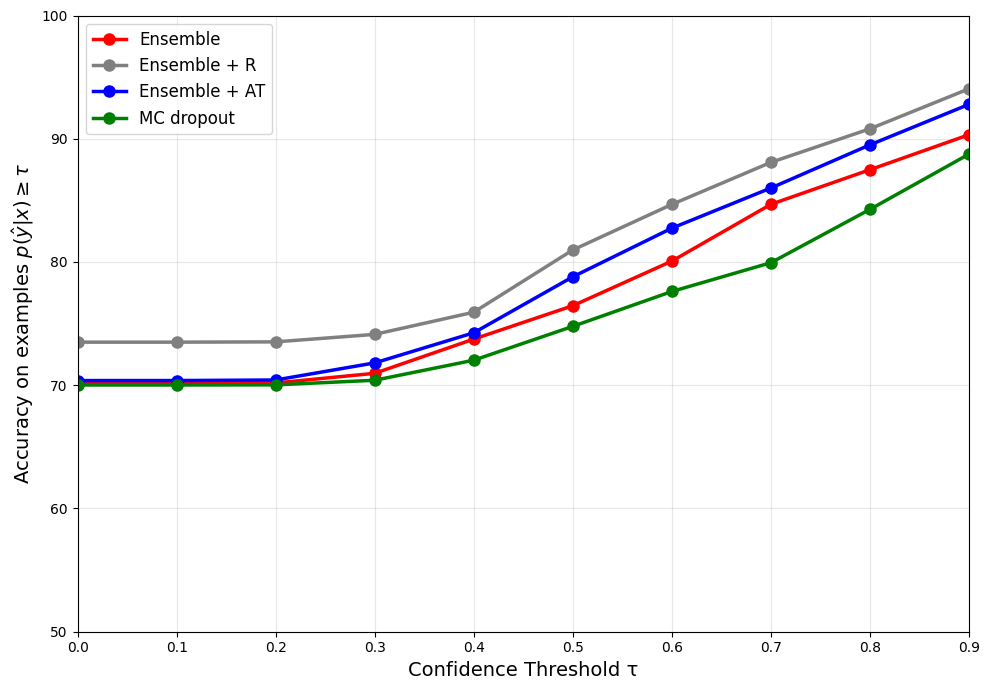


Combined Comparison - All Models on Combined Test Data
Ensemble            : 90.33% accuracy at τ=0.9
Ensemble + R        : 94.05% accuracy at τ=0.9
Ensemble + AT       : 92.79% accuracy at τ=0.9
MC Dropout          : 88.75% accuracy at τ=0.9


In [42]:
# Combined comparison plot - all models on Combined Test Data (like the reference image)
plt.figure(figsize=(10, 7))

# Plot all 4 models using their combined test data
plt.plot(thresholds, combined_accuracies, 'o-', 
         color='red', linewidth=2.5, markersize=8, label='Ensemble')
plt.plot(thresholds, ensemble_r_combined_accuracies, 'o-', 
         color='gray', linewidth=2.5, markersize=8, label='Ensemble + R')
plt.plot(thresholds, ensemble_at_combined_accuracies, 'o-', 
         color='blue', linewidth=2.5, markersize=8, label='Ensemble + AT')
plt.plot(thresholds, mc_combined_accuracies, 'o-', 
         color='green', linewidth=2.5, markersize=8, label='MC dropout')

plt.xlabel('Confidence Threshold τ', fontsize=14)
plt.ylabel('Accuracy on examples $p(\\hat{y}|x) \\geq τ$', fontsize=14)
plt.xlim([0.0, 0.9])
plt.ylim([50, 100])
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

print("\nCombined Comparison - All Models on Combined Test Data")
print("=" * 60)
for model in models:
    print(f"{model['name']:<20}: {model['combined'][-1]:.2f}% accuracy at τ=0.9")
print("=" * 60)

In [43]:
import pandas as pd

# Save all model predictions and accuracies to CSV files


# 1. Save confidence threshold vs accuracy data for all models
threshold_data = {
    'Threshold': thresholds,
    'Ensemble_Train': train_accuracies,
    'Ensemble_Test_MNIST': test_accuracies,
    'Ensemble_Test_NotMNIST': notmnist_accuracies,
    'Ensemble_Combined': combined_accuracies,
    'Ensemble_R_Train': ensemble_r_train_accuracies,
    'Ensemble_R_Test_MNIST': ensemble_r_test_accuracies,
    'Ensemble_R_Test_NotMNIST': ensemble_r_notmnist_accuracies,
    'Ensemble_R_Combined': ensemble_r_combined_accuracies,
    'Ensemble_AT_Train': ensemble_at_train_accuracies,
    'Ensemble_AT_Test_MNIST': ensemble_at_test_accuracies,
    'Ensemble_AT_Test_NotMNIST': ensemble_at_notmnist_accuracies,
    'Ensemble_AT_Combined': ensemble_at_combined_accuracies,
    'MC_Dropout_Train': mc_train_accuracies,
    'MC_Dropout_Test_MNIST': mc_test_accuracies,
    'MC_Dropout_Test_NotMNIST': mc_notmnist_accuracies,
    'MC_Dropout_Combined': mc_combined_accuracies
}

df_threshold = pd.DataFrame(threshold_data)
df_threshold.to_csv('confidence_threshold_accuracies.csv', index=False)
print("✓ Saved: confidence_threshold_accuracies.csv")

# 2. Save sample counts for each threshold
count_data = {
    'Threshold': thresholds,
    'Ensemble_Train_Count': train_counts,
    'Ensemble_Test_MNIST_Count': test_counts,
    'Ensemble_Test_NotMNIST_Count': notmnist_counts,
    'Ensemble_Combined_Count': combined_counts,
    'Ensemble_R_Train_Count': ensemble_r_train_counts,
    'Ensemble_R_Test_MNIST_Count': ensemble_r_test_counts,
    'Ensemble_R_Test_NotMNIST_Count': ensemble_r_notmnist_counts,
    'Ensemble_R_Combined_Count': ensemble_r_combined_counts,
    'Ensemble_AT_Train_Count': ensemble_at_train_counts,
    'Ensemble_AT_Test_MNIST_Count': ensemble_at_test_counts,
    'Ensemble_AT_Test_NotMNIST_Count': ensemble_at_notmnist_counts,
    'Ensemble_AT_Combined_Count': ensemble_at_combined_counts,
    'MC_Dropout_Train_Count': mc_train_counts,
    'MC_Dropout_Test_MNIST_Count': mc_test_counts,
    'MC_Dropout_Test_NotMNIST_Count': mc_notmnist_counts,
    'MC_Dropout_Combined_Count': mc_combined_counts
}

df_counts = pd.DataFrame(count_data)
df_counts.to_csv('confidence_threshold_counts.csv', index=False)
print("✓ Saved: confidence_threshold_counts.csv")

# 3. Save summary statistics
summary_data = {
    'Model': ['Ensemble', 'Ensemble + R', 'Ensemble + AT', 'MC Dropout'],
    'Train_Accuracy_at_0.9': [
        train_accuracies[-1],
        ensemble_r_train_accuracies[-1],
        ensemble_at_train_accuracies[-1],
        mc_train_accuracies[-1]
    ],
    'Test_MNIST_Accuracy_at_0.9': [
        test_accuracies[-1],
        ensemble_r_test_accuracies[-1],
        ensemble_at_test_accuracies[-1],
        mc_test_accuracies[-1]
    ],
    'Test_NotMNIST_Accuracy_at_0.9': [
        notmnist_accuracies[-1],
        ensemble_r_notmnist_accuracies[-1],
        ensemble_at_notmnist_accuracies[-1],
        mc_notmnist_accuracies[-1]
    ],
    'Combined_Accuracy_at_0.9': [
        combined_accuracies[-1],
        ensemble_r_combined_accuracies[-1],
        ensemble_at_combined_accuracies[-1],
        mc_combined_accuracies[-1]
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('model_summary_statistics.csv', index=False)
print("✓ Saved: model_summary_statistics.csv")

print("\n" + "="*60)
print("All data exported successfully!")
print("="*60)
print("\nFiles created:")
print("  1. confidence_threshold_accuracies.csv - Accuracy values for all models")
print("  2. confidence_threshold_counts.csv - Sample counts for each threshold")
print("  3. model_summary_statistics.csv - Summary statistics at τ=0.9")

✓ Saved: confidence_threshold_accuracies.csv
✓ Saved: confidence_threshold_counts.csv
✓ Saved: model_summary_statistics.csv

All data exported successfully!

Files created:
  1. confidence_threshold_accuracies.csv - Accuracy values for all models
  2. confidence_threshold_counts.csv - Sample counts for each threshold
  3. model_summary_statistics.csv - Summary statistics at τ=0.9
